In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

epochs = 15
batch_size = 16
learning_rate = 0.001

Using: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.ImageFolder(
    root="/kaggle/input/datasets/abhishekreddy27/busi-dataset/Dataset_BUSI_with_GT",
    transform=transform
)

print("Classes:", dataset.classes)

Classes: ['benign', 'malignant', 'normal']


In [3]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x


model = CNN(num_classes=len(dataset.classes)).to(device)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [6]:
train_losses = []
train_acc = []

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

Epoch 1/15 | Loss: 0.8620 | Acc: 62.12%
Epoch 2/15 | Loss: 0.6797 | Acc: 70.60%
Epoch 3/15 | Loss: 0.5640 | Acc: 76.23%
Epoch 4/15 | Loss: 0.4295 | Acc: 82.41%
Epoch 5/15 | Loss: 0.3565 | Acc: 85.66%
Epoch 6/15 | Loss: 0.2468 | Acc: 91.13%
Epoch 7/15 | Loss: 0.1561 | Acc: 94.93%
Epoch 8/15 | Loss: 0.1002 | Acc: 96.67%
Epoch 9/15 | Loss: 0.0969 | Acc: 97.23%
Epoch 10/15 | Loss: 0.0456 | Acc: 98.57%
Epoch 11/15 | Loss: 0.0297 | Acc: 99.37%
Epoch 12/15 | Loss: 0.0040 | Acc: 100.00%
Epoch 13/15 | Loss: 0.0014 | Acc: 100.00%
Epoch 14/15 | Loss: 0.0020 | Acc: 99.92%
Epoch 15/15 | Loss: 0.0176 | Acc: 99.52%


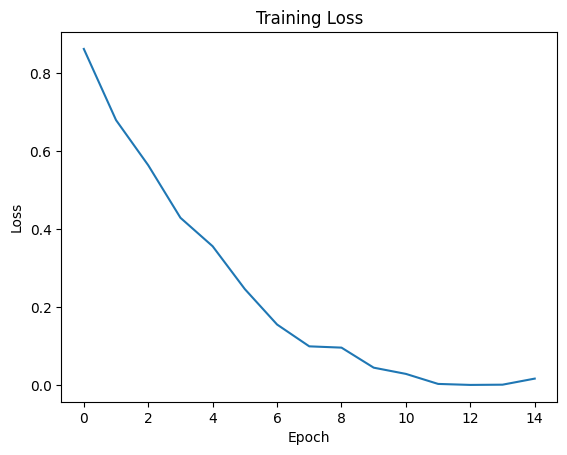

In [7]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

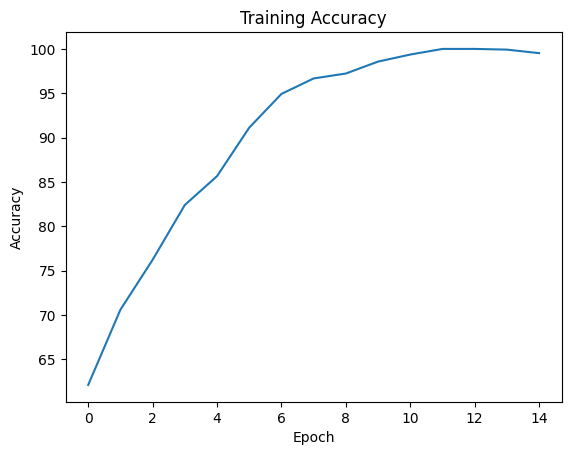

In [8]:
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

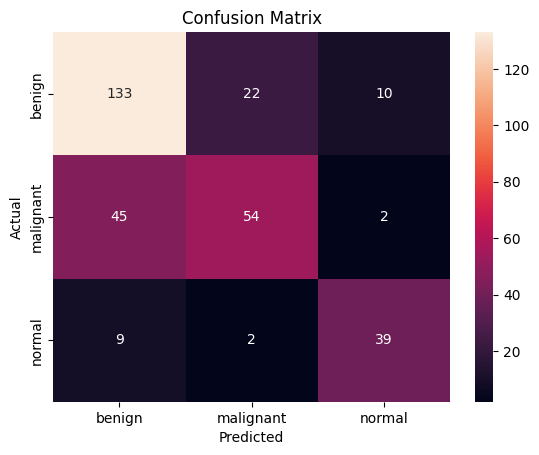

In [9]:
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=dataset.classes, 
            yticklabels=dataset.classes)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

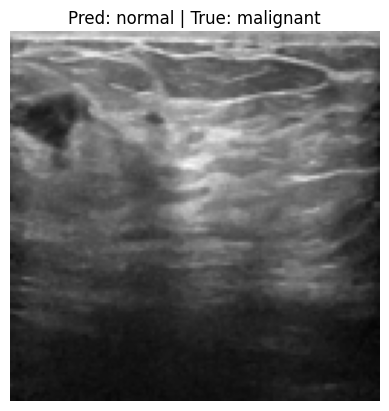

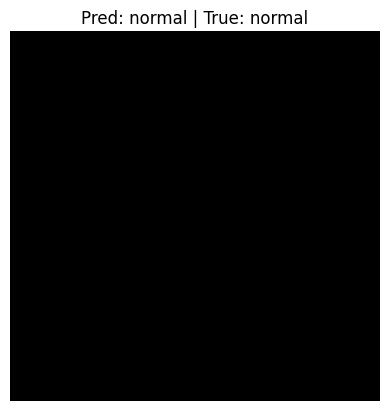

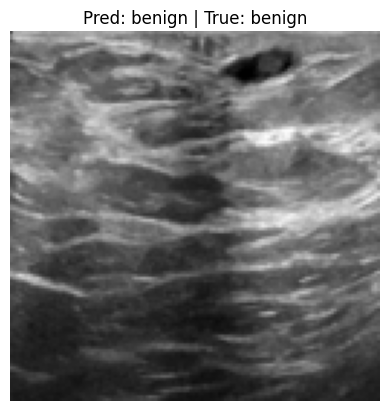

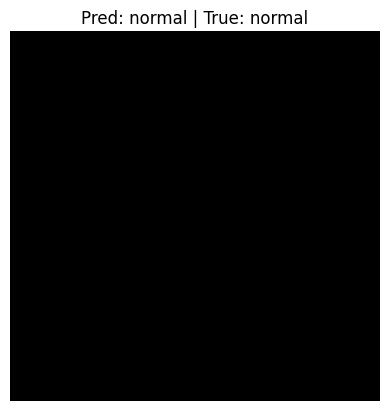

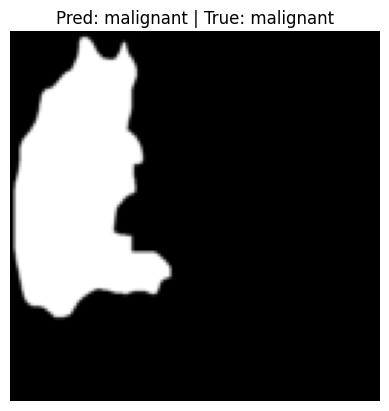

In [10]:
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)

outputs = model(imgs)
_, preds = torch.max(outputs, 1)

imgs = imgs.cpu()

for i in range(5):
    plt.imshow(np.transpose(imgs[i], (1,2,0)))
    plt.title(f"Pred: {dataset.classes[preds[i]]} | True: {dataset.classes[labels[i]]}")
    plt.axis('off')
    plt.show()